In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
df=pd.read_csv('ANALYSIS_OF_IPL_2025_BATTERS_ARAVIND_NAYINI_2024127536.csv')

In [15]:
team_summary = df.groupby('Team').agg({'Runs': ['sum', 'mean'],'SR': 'mean',
                                       '100s': 'sum','50s': 'sum',
                                       'Matches': 'max'}).round(2)

team_summary.columns = ['Total_Runs', 'Avg_Runs_per_Player', 'Avg_SR',
                        'Total_100s', 'Total_50s', 'Matches']
team_summary = team_summary.sort_values('Total_Runs', ascending=False)
print("Team Batting Summary:")
team_summary


Team Batting Summary:


,Total_Runs,Avg_Runs_per_Player,Avg_SR,Total_100s,Total_50s,Matches
Team,,,,,,
PBKS,3000,200.00,144.91,1,18,17
MI,2802,175.12,137.22,0,15,16
GT,2766,197.57,142.95,1,18,15
LSG,2598,173.20,140.85,2,19,14
RCB,2539,181.36,141.39,0,22,15
RR,2496,146.82,137.22,1,14,14
DC,2386,140.35,119.01,1,9,14
SRH,2378,169.86,129.77,3,8,14
CSK,2315,121.84,130.35,0,13,14


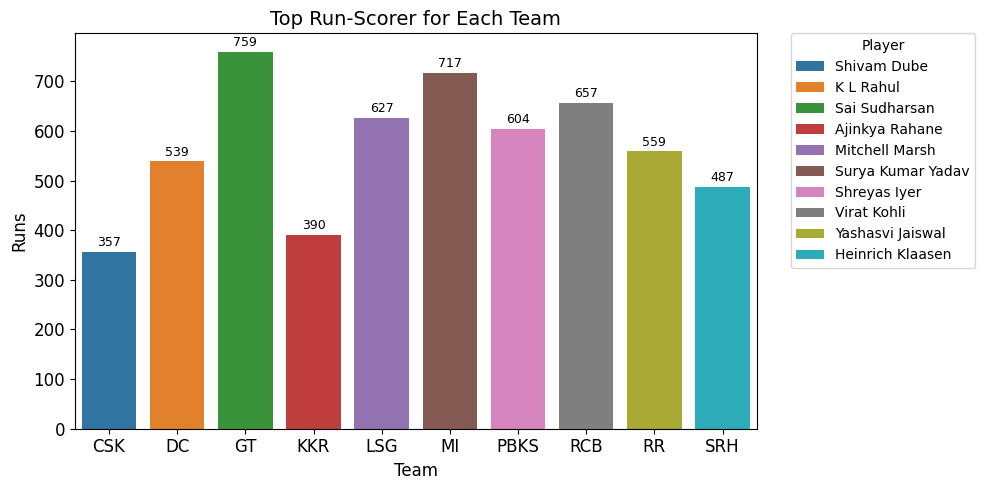

In [16]:
idx = df.groupby("Team")["Runs"].idxmax()
top_per_team = df.loc[idx]

plt.figure(figsize=(10,5))
ax = sns.barplot(data=top_per_team, x="Team", y="Runs", hue="Player Name")
plt.title("Top Run-Scorer for Each Team",fontsize=14)
plt.ylabel("Runs",fontsize=12)
plt.xlabel("Team",fontsize=12)

for p in ax.patches:
    height = p.get_height()
    if height == 0:
        continue
    ax.annotate(f"{int(height)}",(p.get_x() + p.get_width()/2, height),
                ha="center",va="bottom",fontsize=9,xytext=(0, 2),
                textcoords="offset points")

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles,labels,title="Player",bbox_to_anchor=(1.05, 1),
          loc="upper left",borderaxespad=0.)
plt.tight_layout()
plt.savefig("bar1.png", dpi=900, bbox_inches="tight")
plt.show()


/tmp/ipython-input-1513645384.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


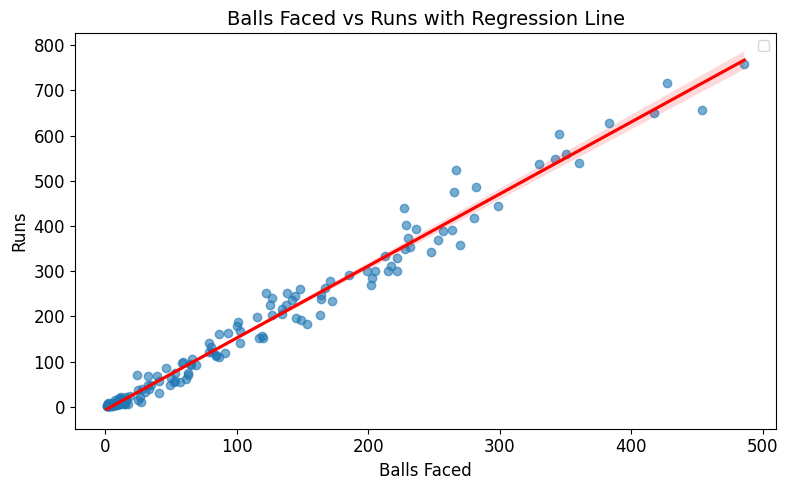

In [17]:
plt.figure(figsize=(8,5))
sns.regplot(data=df, x="BF",y="Runs",scatter_kws={"alpha": 0.6},
            line_kws={"color": "red"})
plt.title("Balls Faced vs Runs with Regression Line",fontsize=14)
plt.xlabel("Balls Faced",fontsize=12)
plt.ylabel("Runs",fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig("rel1.png", dpi=900, bbox_inches="tight")
plt.show()


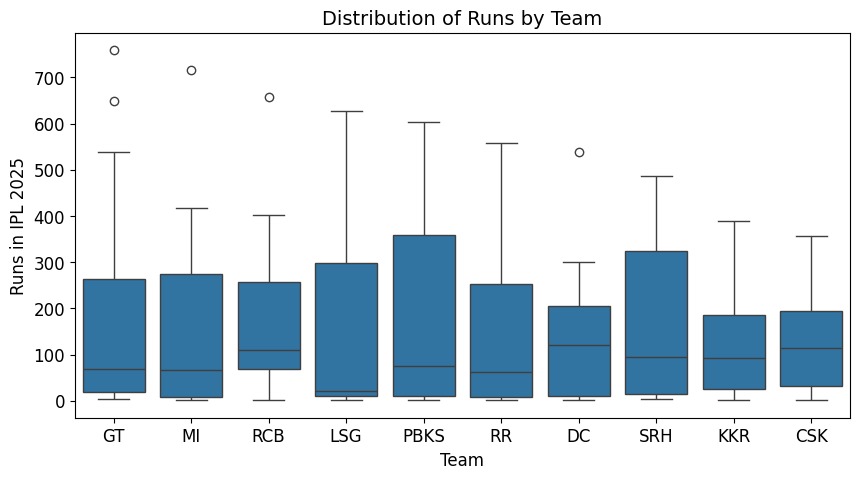

In [18]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x="Team", y="Runs")
plt.title("Distribution of Runs by Team",fontsize=14)
plt.xlabel("Team",fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.ylabel("Runs in IPL 2025",fontsize=12)
plt.savefig("box1.png", dpi=900, bbox_inches="tight")
plt.show()
